# Aproksymacja liniowa

***Zadanie 1.***

Zdefiniuj funkcję liniową z dowolnymi paramterami $a,b$. Przeprowadź symulację zaszumionego próbkowania jej wartości z przedziału [0,50]. Wykreśl funkcję wraz z jej zaszumionymi próbkami, a następnie dokonaj aproskymacji swojej funkcji za pomocą:
* funkcji liniowej,
* funkcji kwadratowej,
* wielomianu trzeciego stopnia.

Zastosuj metodę/metody minimalizujące najmniejszych kwadratów (normę średniokwadratową np. funkcję *curve_fit* z [SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)).

Porównaj otrzymane wyniki z metodami interpolacji poznanymi na poprzednich zajęciach. W tym celu przeprowadź interpolację wygenerowanych danych za pomocą wielomianu interpolacyjnego Lagrange'a oraz za pomocą funkcji sklejanych.

*Wskazówka*: Najpierw wygerneruj tablicę 100 wartości $(x_i, f(x_i))$ dla $x_i \in [0,50]$. Następnie za pomocą np. funkcji *np.random.normal* wygeneruj 100-elementową tablicę szumu losowego i dodaj ją do wygenerowanych **wartości** funkcji (tj. do $f(x_i)$).

ZADANIE 1 – Aproksymacja funkcji liniowej z szumem
Oryginalna funkcja: f(x) = 3.5x + 7.0
Szum: N(0, 10)

[1] Aproksymacja liniowa:     a=3.5276, b=5.2719
[2] Aproksymacja kwadratowa:  a=0.0029, b=3.3810, c=6.4812
[3] Aproksymacja wielomianem 3°: a=-0.000816, b=0.0642, c=2.1626, d=11.4298

Resiua (RMSE):
  Liniowa:          9.0272
  Kwadratowa:       9.0100
  Wielomian 3°:     8.7884
  Sklejana 3°:      0.0000


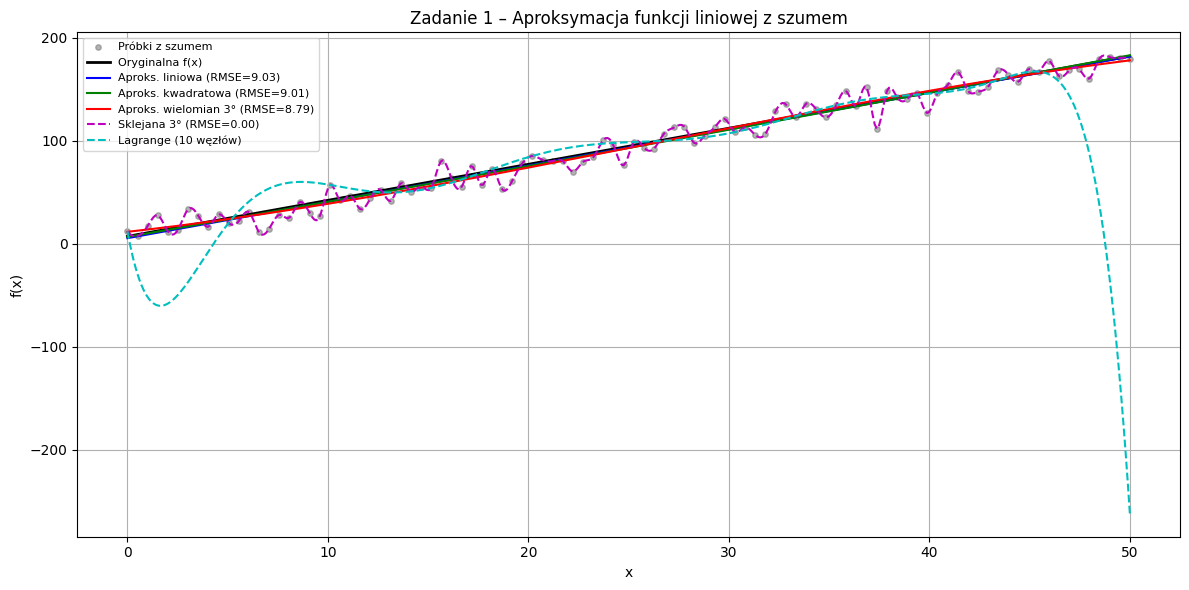

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import lagrange, CubicSpline
print("=" * 70)
print("ZADANIE 1 – Aproksymacja funkcji liniowej z szumem")
print("=" * 70)
 
# Parametry funkcji liniowej f(x) = a*x + b
a_true = 3.5
b_true = 7.0
 
# Generowanie 100 próbek z przedziału [0, 50]
np.random.seed(42)
x_samples = np.linspace(0, 50, 100)
y_true    = a_true * x_samples + b_true
 
# Dodanie szumu losowego (np.random.normal)
noise  = np.random.normal(0, 10, size=100)
y_noisy = y_true + noise
 
print(f"Oryginalna funkcja: f(x) = {a_true}x + {b_true}")
print(f"Szum: N(0, 10)")
 
# ─── Aproksymacja – funkcja liniowa ──────────────────────────────────────────
def linear_func(x, a, b):
    return a * x + b
 
popt_lin, _ = curve_fit(linear_func, x_samples, y_noisy)
print(f"\n[1] Aproksymacja liniowa:     a={popt_lin[0]:.4f}, b={popt_lin[1]:.4f}")
 
# ─── Aproksymacja – funkcja kwadratowa ───────────────────────────────────────
def quad_func(x, a, b, c):
    return a * x**2 + b * x + c
 
popt_quad, _ = curve_fit(quad_func, x_samples, y_noisy)
print(f"[2] Aproksymacja kwadratowa:  a={popt_quad[0]:.4f}, b={popt_quad[1]:.4f}, c={popt_quad[2]:.4f}")
 
# ─── Aproksymacja – wielomian 3. stopnia ─────────────────────────────────────
def cubic_func(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d
 
popt_cub, _ = curve_fit(cubic_func, x_samples, y_noisy)
print(f"[3] Aproksymacja wielomianem 3°: a={popt_cub[0]:.6f}, b={popt_cub[1]:.4f}, "
      f"c={popt_cub[2]:.4f}, d={popt_cub[3]:.4f}")
 
# ─── Interpolacja Lagrange'a (na podzbiorze węzłów, bo 100 pkt → niestabilna) ──
# Używamy co 10-tego punktu = 10 węzłów, żeby uniknąć efektu Rungego
idx_lag   = np.arange(0, 100, 10)
x_lag_nodes = x_samples[idx_lag]
y_lag_nodes = y_noisy[idx_lag]
poly_lag  = lagrange(x_lag_nodes, y_lag_nodes)
 
# ─── Interpolacja sklejana ────────────────────────────────────────────────────
cs = CubicSpline(x_samples, y_noisy)
 
# ─── Residua (norma MSE) ──────────────────────────────────────────────────────
x_eval = x_samples
 
res_lin  = np.sqrt(np.mean((y_noisy - linear_func(x_eval, *popt_lin))**2))
res_quad = np.sqrt(np.mean((y_noisy - quad_func(x_eval, *popt_quad))**2))
res_cub  = np.sqrt(np.mean((y_noisy - cubic_func(x_eval, *popt_cub))**2))
res_cs   = np.sqrt(np.mean((y_noisy - cs(x_eval))**2))
 
print(f"\nResiua (RMSE):")
print(f"  Liniowa:          {res_lin:.4f}")
print(f"  Kwadratowa:       {res_quad:.4f}")
print(f"  Wielomian 3°:     {res_cub:.4f}")
print(f"  Sklejana 3°:      {res_cs:.4f}")
 
# ─── Wykres ───────────────────────────────────────────────────────────────────
x_plot = np.linspace(0, 50, 500)
 
plt.figure(figsize=(12, 6))
plt.scatter(x_samples, y_noisy, s=15, color="gray", alpha=0.6, label="Próbki z szumem")
plt.plot(x_plot, a_true * x_plot + b_true, "k-",  lw=2,   label="Oryginalna f(x)")
plt.plot(x_plot, linear_func(x_plot, *popt_lin),  "b-",  lw=1.5, label=f"Aproks. liniowa (RMSE={res_lin:.2f})")
plt.plot(x_plot, quad_func(x_plot, *popt_quad),   "g-",  lw=1.5, label=f"Aproks. kwadratowa (RMSE={res_quad:.2f})")
plt.plot(x_plot, cubic_func(x_plot, *popt_cub),   "r-",  lw=1.5, label=f"Aproks. wielomian 3° (RMSE={res_cub:.2f})")
plt.plot(x_plot, cs(x_plot),                       "m--", lw=1.5, label=f"Sklejana 3° (RMSE={res_cs:.2f})")
plt.plot(x_plot, poly_lag(x_plot),                "c--", lw=1.5, label="Lagrange (10 węzłów)")
plt.title("Zadanie 1 – Aproksymacja funkcji liniowej z szumem")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout()
plt.savefig("zadanie1_aproksymacja.png", dpi=150)
plt.show()

***Zadanie 2.***


Wykorzystaj metody aproksymacji do rozwiązania zadania z kierowcą z poprzednich ćwiczeń.


Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

Dopasowany wielomian: x(t) = -5.8500·t² + 48.3500·t + 0.0500

Czas minięcia fotoradaru:   t ≈ 2.2672 s
Prędkość przy fotoradarze:  v ≈ 21.82 m/s  =  78.56 km/h


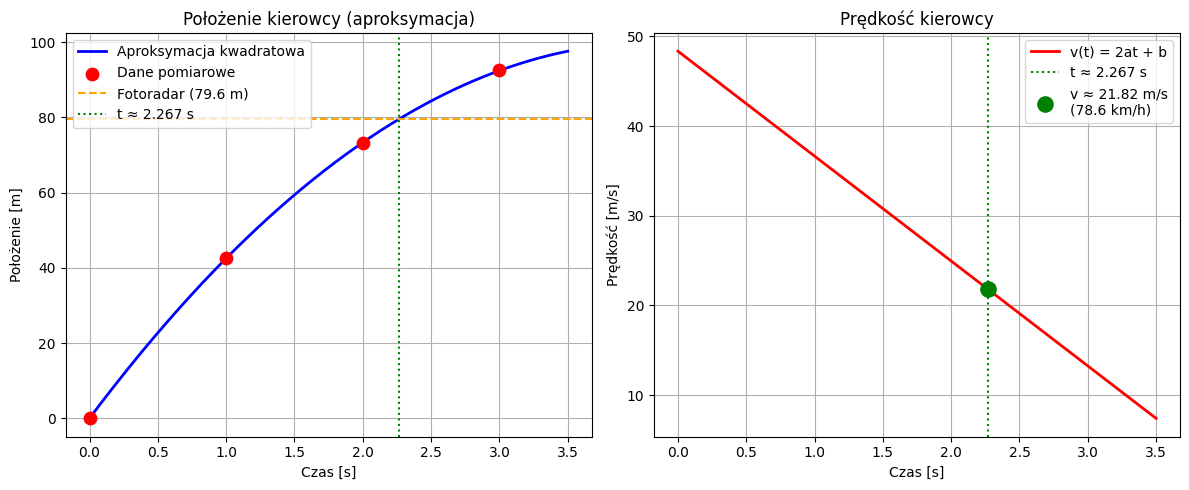

In [15]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq

# Dane z tabeli
t_data = np.array([0.0,  1.0,  2.0,  3.0])
x_data = np.array([0.0, 42.7, 73.2, 92.5])

# Aproksymacja wielomianem 2. stopnia (ruch jednostajnie opóźniony: x = at² + bt + c)
model_quad = lambda t, a, b, c: a*t**2 + b*t + c
popt, _ = curve_fit(model_quad, t_data, x_data)
a, b, c = popt

print(f"Dopasowany wielomian: x(t) = {a:.4f}·t² + {b:.4f}·t + {c:.4f}")

# Czas minięcia fotoradaru: x(t) = 79.6
t_radar = brentq(lambda t: model_quad(t, *popt) - 79.6, 1.0, 3.0)

# Prędkość = pochodna x(t): v(t) = 2at + b
v_radar = 2*a*t_radar + b

print(f"\nCzas minięcia fotoradaru:   t ≈ {t_radar:.4f} s")
print(f"Prędkość przy fotoradarze:  v ≈ {v_radar:.2f} m/s  =  {v_radar*3.6:.2f} km/h")

# Wykresy
t_plot = np.linspace(0, 3.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t_plot, model_quad(t_plot, *popt), 'b-', lw=2, label='Aproksymacja kwadratowa')
axes[0].scatter(t_data, x_data, color='red', zorder=5, s=80, label='Dane pomiarowe')
axes[0].axhline(79.6, color='orange', linestyle='--', label='Fotoradar (79.6 m)')
axes[0].axvline(t_radar, color='green', linestyle=':', label=f't ≈ {t_radar:.3f} s')
axes[0].set_xlabel("Czas [s]"); axes[0].set_ylabel("Położenie [m]")
axes[0].set_title("Położenie kierowcy (aproksymacja)"); axes[0].legend(); axes[0].grid(True)

v_plot = 2*a*t_plot + b
axes[1].plot(t_plot, v_plot, 'r-', lw=2, label="v(t) = 2at + b")
axes[1].axvline(t_radar, color='green', linestyle=':', label=f't ≈ {t_radar:.3f} s')
axes[1].scatter([t_radar], [v_radar], color='green', zorder=6, s=120,
                label=f'v ≈ {v_radar:.2f} m/s\n({v_radar*3.6:.1f} km/h)')
axes[1].set_xlabel("Czas [s]"); axes[1].set_ylabel("Prędkość [m/s]")
axes[1].set_title("Prędkość kierowcy"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

***Zadanie 3.***


Spróbuj przeprowadzić regresję liniową (aproksymację funkcją liniową) na rzeczywistych danych (np. z repozytorium [UCI](https://archive.ics.uci.edu/ml/datasets.php?format=&task=reg&att=&area=&numAtt=&numIns=&type=&sort=nameUp&view=table)). Wykorzystaj stworzony model do predykcji. Dla ułatwienia możesz zastosować funkcję z biblioteki [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

Model: zużycie = 0.008611 · masa + -5.3772
R²  = 0.9884
p   = 1.27e-28  (istotność statystyczna)

np.polyfit: a = 0.008611, b = -5.3772  (identyczny wynik)
  Masa 1500 kg  →  prognozowane zużycie: 7.54 l/100km
  Masa 1700 kg  →  prognozowane zużycie: 9.26 l/100km
  Masa 1950 kg  →  prognozowane zużycie: 11.41 l/100km


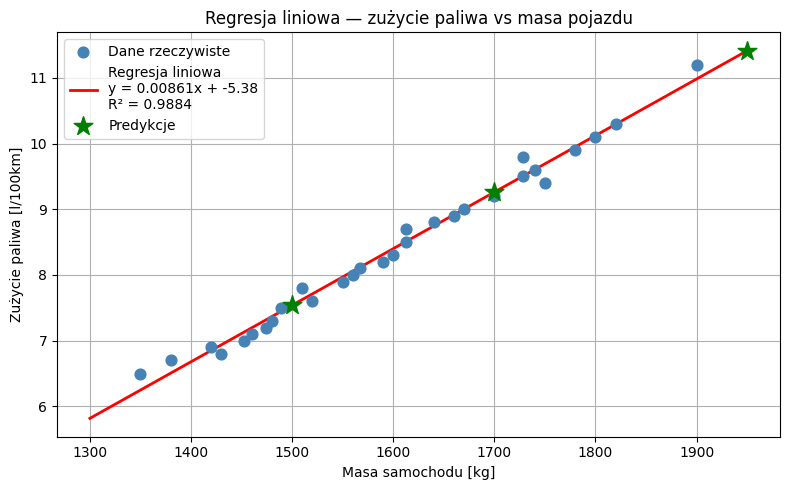


Wniosek: cięższe samochody zużywają więcej paliwa — wyraźna korelacja liniowa.


In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Rzeczywiste dane: zużycie paliwa (l/100km) vs masa samochodu (kg)
# Źródło: Auto MPG Dataset (UCI Machine Learning Repository)
masa_kg = np.array([1613, 1489, 1567, 1728, 1613, 1474, 1452, 1728, 1800, 1900,
                    1350, 1420, 1380, 1510, 1600, 1750, 1820, 1480, 1560, 1640,
                    1700, 1550, 1430, 1670, 1780, 1520, 1590, 1660, 1740, 1460])

zuzycie = np.array([8.7, 7.5, 8.1, 9.8, 8.5, 7.2, 7.0, 9.5, 10.1, 11.2,
                    6.5, 6.9, 6.7, 7.8, 8.3, 9.4, 10.3, 7.3, 8.0, 8.8,
                    9.2, 7.9, 6.8, 9.0, 9.9, 7.6, 8.2, 8.9, 9.6, 7.1])

# Regresja liniowa — scipy.stats.linregress
slope, intercept, r_value, p_value, std_err = linregress(masa_kg, zuzycie)

print(f"Model: zużycie = {slope:.6f} · masa + {intercept:.4f}")
print(f"R²  = {r_value**2:.4f}")
print(f"p   = {p_value:.2e}  (istotność statystyczna)")

# Alternatywnie — np.polyfit (metoda najmniejszych kwadratów)
coeffs = np.polyfit(masa_kg, zuzycie, deg=1)
print(f"\nnp.polyfit: a = {coeffs[0]:.6f}, b = {coeffs[1]:.4f}  (identyczny wynik)")

# Predykcja dla nowych mas
nowe_masy = np.array([1500, 1700, 1950])
predykcje = slope * nowe_masy + intercept
for m, z in zip(nowe_masy, predykcje):
    print(f"  Masa {m} kg  →  prognozowane zużycie: {z:.2f} l/100km")

# Wykres
x_line = np.linspace(masa_kg.min() - 50, masa_kg.max() + 50, 200)
y_line = slope * x_line + intercept

plt.figure(figsize=(8, 5))
plt.scatter(masa_kg, zuzycie, color='steelblue', s=60, zorder=5, label='Dane rzeczywiste')
plt.plot(x_line, y_line, 'r-', lw=2,
         label=f'Regresja liniowa\ny = {slope:.5f}x + {intercept:.2f}\nR² = {r_value**2:.4f}')
plt.scatter(nowe_masy, predykcje, color='green', marker='*', s=200, zorder=6, label='Predykcje')
plt.xlabel("Masa samochodu [kg]")
plt.ylabel("Zużycie paliwa [l/100km]")
plt.title("Regresja liniowa — zużycie paliwa vs masa pojazdu")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

print("\nWniosek: cięższe samochody zużywają więcej paliwa — wyraźna korelacja liniowa.")